# Pairs Trading

หลักการพื้นฐานคือ Mean Reversion (การกลับสู่ค่าเฉลี่ย) เราเชื่อว่าสินทรัพย์สองตัวที่มีพื้นฐานคล้ายกัน ราคาควรจะเคลื่อนไหวไปด้วยกัน หากวันหนึ่งราคาแยกออกจากกัน (Divergence) เราจะเดิมพันว่าเดี๋ยวมันจะกลับมาชิดกันเหมือนเดิม

แนวคิด: The Drunk and the Dog (คนเมากับหมา)
เพื่อให้เห็นภาพชัดเจน:

- Correlation (สหสัมพันธ์): เหมือนรถสองคันวิ่งไปบนถนนทางเดียวกัน แต่อาจจะอยู่ห่างกันเท่าไหร่ก็ได้ (แค่วิ่งทิศเดียวกัน)
- Cointegration (สหรวม):  เหมือน "คนเมาจูงหมา" เดินกลับบ้าน ทั้งคู่เดินเซไปเซมา (Random Walk) แต่มีสายจูงผูกกันไว้ ทำให้ระยะห่างระหว่างคนกับหมาจะไม่เกินความยาวเชือกเสมอ

ใน Pairs Trading เราหาคู่ที่ Cointegrated (มีสายจูง) ไม่ใช่แค่ Correlated

คณิตศาสตร์เบื้องหลัง (The Math)

1. Model the Spread: เราสร้างสมการความสัมพันธ์:
    $$P_A = \alpha + \beta P_B + \epsilon$$

    โดยที่ 
    - $P_A$ คือราคาสินทรัพย์ A, $P_B$ คือราคาสินทรัพย์ B
    
    - $\alpha$ (Alpha): จุดตัดแกน (Intercept) หรือส่วนต่างพื้นฐาน

    - $\beta$ (Beta): อัตราส่วนความสัมพันธ์ (Slope) หรือ Hedge Ratio

    - $\epsilon$ (Epsilon): ส่วนที่เหลือ (Residual) หรือ Spread ที่เราจะเอามาเทรด

2. Stationarity (ความคงที่): เราต้องทดสอบว่า Spread ($\epsilon$) มีคุณสมบัติ Stationary หรือไม่ (คือมีค่าเฉลี่ยคงที่ ไม่วิ่งหนีไปเรื่อยๆ) เครื่องมือที่ใช้ทดสอบคือ Augmented Dickey-Fuller (ADF) Test

3. Z-Score (สัญญาณเข้าซื้อขาย): เมื่อเราได้ Spread มาแล้ว เราจะแปลงเป็นค่ามาตรฐาน (Standard Score) เพื่อดูว่ามัน "ห่าง" จากปกติแค่ไหน:

    $$Z = \frac{Spread - Mean(Spread)}{StdDev(Spread)}$$

    - ถ้า $Z > 2$: Spread กว้างผิดปกติ (Asset A แพงเกินไปเทียบกับ B) -> Short A / Long B
    - ถ้า $Z < -2$: Spread แคบผิดปกติ (Asset A ถูกเกินไปเทียบกับ B) -> Long A / Short B
    - ถ้า $Z = 0$: ปิดสถานะ (Take Profit)

Use Case ในชีวิตจริง (Real World Examples)

ในโลกความเป็นจริง เรามักจับคู่สินทรัพย์ที่อยู่ใน Sector เดียวกัน หรือได้รับผลกระทบจาก Macroeconomic ปัจจัยเดียวกัน

1. Competitor Pairs (คู่แข่งโดยตรง):

    - Coca-Cola (KO) vs Pepsi (PEP): คลาสสิกที่สุด ทั้งคู่ขายน้ำดำเหมือนกัน หากวันหนึ่ง KO พุ่งขึ้นแต่ PEP นิ่ง โดยไม่มีข่าวร้ายเฉพาะตัวของ PEP เราอาจ Short KO และ Long PEP

    - Visa (V) vs Mastercard (MA)

2. Commodity vs Producer (สินค้าโภคภัณฑ์ vs ผู้ผลิต):

    - ราคาทองคำ (Gold Futures) vs หุ้นเหมืองทอง (GDX ETF): ปกติหุ้นเหมืองควรวิ่งตามราคาทอง ถ้าทองขึ้นแต่หุ้นเหมืองไม่ขึ้น อาจเกิดโอกาสทำกำไร

3. Share Class Arbitrage (หุ้นบริษัทเดียวกันต่างคลาส):

    - GOOG vs GOOGL (Alphabet): เป็นบริษัทเดียวกัน ต่างกันแค่สิทธิโหวต ราคาควรวิ่งขนานกันตลอด

ความเสี่ยง (Risks):

    - Fundamental Break: "เชือกขาด" เช่น บริษัท A เกิดการโกงบัญชี หรือถูกฟ้องร้อง ทำให้ราคาตกลงและไม่กลับมาหา B อีกเลย (Cointegration พัง)

    - Execution Risk: การส่งคำสั่งซื้อและขายต้องเกิดขึ้นพร้อมกันทันที

## Code Implementation

Scenario: เราจะลองทดสอบคู่ Pepsi (PEP) และ Coca-Cola (KO)

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

In [3]:
# 1. ดึงข้อมูลราคา (Data Ingestion)
start_date = '2020-01-01'
end_date = '2023-12-31'
tickers = ['PEP', 'KO']
data = yf.download(tickers, start=start_date, end=end_date,auto_adjust=False)['Adj Close']

[*********************100%***********************]  2 of 2 completed


In [4]:
# 2. ตรวจสอบ Cointegration (The "Leash" Test)
# Null Hypothesis: ทั้งสองซีรีส์ไม่มีความสัมพันธ์แบบ Cointegrated
score, pvalue, _ = coint(data['PEP'], data['KO'])

print(f"Cointegration Test P-value: {pvalue:.4f}")
if pvalue < 0.05:
    print("Result: Cointegrated (มีสายจูงกัน เทรดได้!)")
else:
    print("Result: Not Cointegrated (แยกย้าย อย่าเทรดคู่นี้)")

Cointegration Test P-value: 0.0920
Result: Not Cointegrated (แยกย้าย อย่าเทรดคู่นี้)


In [ ]:
# 3. สร้าง Spread และ Z-Score
# หา Hedge Ratio (Beta) ด้วย Linear Regression
S1 = data['PEP'] # ตัวแปรอิสระ (X)
S2 = data['KO'] # ตัวแปรตาม (Y)

# เพิ่มค่าคงที่ (Constant) เพื่อให้สมการมีจุดตัดแกน (Alpha)
S1 = sm.add_constant(S1)

# คำนวณสมการถดถอย (Ordinary Least Squares - OLS)
results = sm.OLS(S2, S1).fit()

# เอา constant ออกเพื่อคำนวณ spread
S1 = S1['PEP'] 

# ดึงค่า Beta ออกมา
b = results.params['PEP'] # Hedge Ratio

# คำนวณ Spread
spread = S2 - b * S1

# คำนวณ Z-Score แบบ Rolling (เพื่อให้ Dynamic ตามตลาด)
window = 30 # มองย้อนหลัง 30 วัน
spread_mean = spread.rolling(window=window).mean()
spread_std = spread.rolling(window=window).std()

# คำนวณ Z-Score
z_score = (spread - spread_mean) / spread_std

ที่มาของการคำนวณ Spread คือแทนที่เราจะดูราคา KO หรือ PEP เดี่ยวๆ เรามาดูค่า spread แทน ซึ่งกราฟของมันควรจะวิ่งขึ้นๆ ลงๆ อยู่รอบแกนกลาง (ไม่พุ่งขึ้นฟ้าเหมือนราคาหุ้นปกติ)

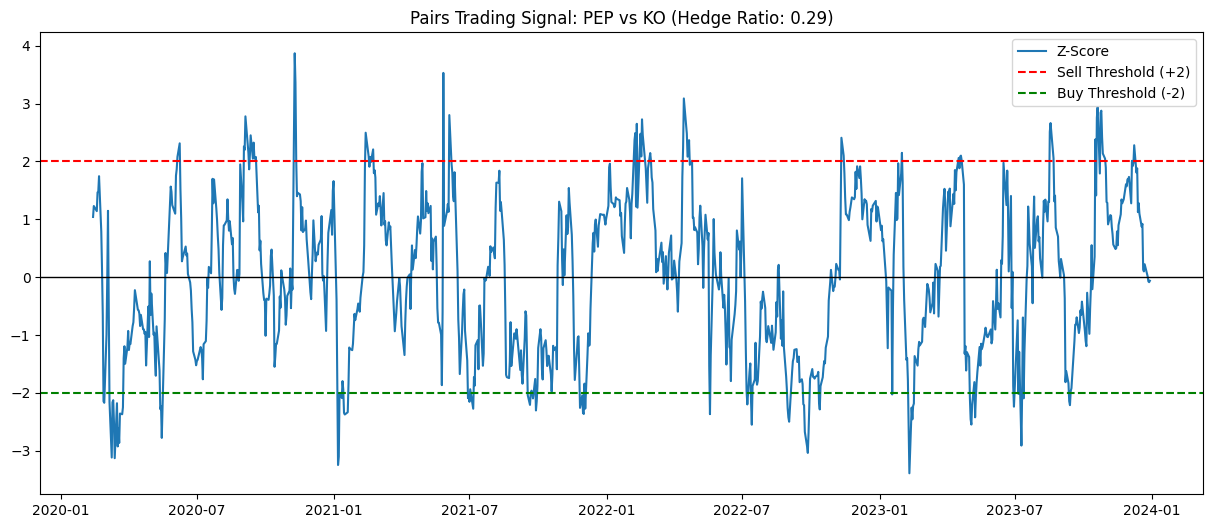

In [6]:
# 4. Visualization (แสดงผล)
plt.figure(figsize=(15, 6))
plt.plot(z_score, label='Z-Score')
plt.axhline(0, color='black', lw=1)
plt.axhline(2.0, color='red', linestyle='--', label='Sell Threshold (+2)')
plt.axhline(-2.0, color='green', linestyle='--', label='Buy Threshold (-2)')
plt.legend()
plt.title(f'Pairs Trading Signal: PEP vs KO (Hedge Ratio: {b:.2f})')
plt.show()

อธิบายโค้ด:
1. coint(): คือหัวใจสำคัญ ถ้า P-value > 0.05 แปลว่าคู่นี้ไม่มีความสัมพันธ์ระยะยาวที่เชื่อถือได้ (Mean Reversion ไม่ทำงาน) ห้ามเทรด

2. Hedge Ratio ($b$): เราไม่ได้ซื้อ 1 หุ้นต่อ 1 หุ้นเสมอไป เราต้องถ่วงน้ำหนักตามราคาและความผันผวน ตัวแปร b บอกเราว่าต้องซื้อ/ขายสัดส่วนเท่าไหร่

3. Rolling Z-Score: การใช้ Rolling Window สำคัญมาก เพราะความสัมพันธ์ในอดีตเมื่อ 2 ปีก่อนอาจใช้ไม่ได้กับปัจจุบัน เราจึงดูค่าเฉลี่ยย้อนหลังแค่ช่วงสั้นๆ (เช่น 30-60 วัน)

## Backtesting: จำลองการเทรด PEP vs KO

เพิ่ม Logic "State Machine" เข้าไป:

- เปิดสถานะ (Open): เมื่อ Z-Score ทะลุ ±2

- ปิดสถานะ (Close/Take Profit): เมื่อ Z-Score วิ่งกลับมาแตะ 0 (Mean) หรือทะลุไปอีกฝั่ง

- Stop Loss: (เพื่อความง่าย จะยังไม่ใส่ในเวอร์ชันแรก แต่อย่าลืมว่าของจริงต้องมี)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# --- (จากโค้ดก่อนหน้า เรามีตัวแปร spread, z_score) ---
# จำลอง Data ขึ้นมาใหม่เพื่อให้ Code นี้รันได้ในตัวเอง
# แต่ในการใช้งานจริง ให้ใช้ spread และ z_score จากโค้ดส่วนที่แล้วได้

# สร้าง DataFrame เพื่อเก็บข้อมูลการ Backtest
bt_df = pd.DataFrame(index=spread.index)
bt_df['Spread'] = spread
bt_df['Z_Score'] = z_score
bt_df['Position'] = 0 # 0=No Position, 1=Long Spread, -1=Short Spread

In [9]:
# --- Logic การเทรด (State Machine) ---
# เราต้องวน Loop เพราะการถือสถานะขึ้นอยู่กับสถานะก่อนหน้า (State Dependent)
status = 0 # 0: ว่าง, 1: ถือ Long, -1: ถือ Short
entry_z = 2.0
exit_z = 0.0

positions = []
for z in bt_df['Z_Score']:
    # กรณีพอร์ตว่าง (ไม่มีของ)
    if status == 0:
        if z < -entry_z: # Spread ต่ำเกินไป -> ซื้อ (Long Spread)
            status = 1
        elif z > entry_z: # Spread สูงเกินไป -> ขาย (Short Spread)
            status = -1
    
    # กรณีถือ Long Spread อยู่ (รอขายทำกำไร)
    elif status == 1:
        if z >= exit_z: # กลับมาที่ค่าเฉลี่ย -> ปิดสถานะ
            status = 0
            
    # กรณีถือ Short Spread อยู่ (รอซื้อคืนทำกำไร)
    elif status == -1:
        if z <= -exit_z: # กลับมาที่ค่าเฉลี่ย -> ปิดสถานะ
            status = 0
            
    positions.append(status)

bt_df['Position'] = positions

In [10]:
# --- คำนวณกำไร/ขาดทุน (PNL Calculation) ---
# Spread Return: การเปลี่ยนแปลงของ Spread ในแต่ละวัน
# ถ้าเรา Long Spread (Position=1) เรากำไรเมื่อ Spread เพิ่มขึ้น
# ถ้าเรา Short Spread (Position=-1) เรากำไรเมื่อ Spread ลดลง

bt_df['Spread_Change'] = bt_df['Spread'] - bt_df['Spread'].shift(1)
bt_df['Daily_PnL'] = bt_df['Position'].shift(1) * bt_df['Spread_Change'] 
# shift(1) เพราะ Position วันนี้ จะส่งผลต่อกำไรของวันพรุ่งนี้

bt_df['Cumulative_PnL'] = bt_df['Daily_PnL'].cumsum()

In [14]:
# --- แสดงผล ---
plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

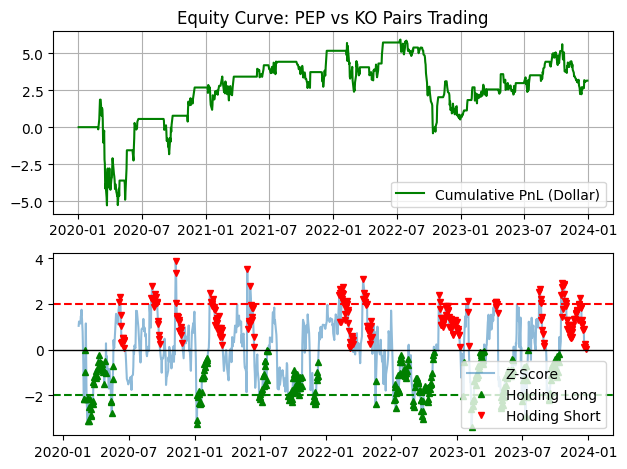

In [15]:
# กราฟ 1: PNL Curve (Equity Curve)
plt.subplot(2, 1, 1)
plt.plot(bt_df['Cumulative_PnL'], color='green', label='Cumulative PnL (Dollar)')
plt.title('Equity Curve: PEP vs KO Pairs Trading')
plt.grid(True)
plt.legend()

# กราฟ 2: Z-Score และจุดเข้าออก
plt.subplot(2, 1, 2)
plt.plot(bt_df['Z_Score'], label='Z-Score', alpha=0.5)
plt.plot(bt_df[bt_df['Position'] == 1].index, bt_df['Z_Score'][bt_df['Position'] == 1], '^', markersize=4, color='g', label='Holding Long')
plt.plot(bt_df[bt_df['Position'] == -1].index, bt_df['Z_Score'][bt_df['Position'] == -1], 'v', markersize=4, color='r', label='Holding Short')
plt.axhline(0, color='black', lw=1)
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='green', linestyle='--')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [16]:
# สรุปผล
total_profit = bt_df['Cumulative_PnL'].iloc[-1]
print(f"Total Profit from Spread: ${total_profit:.2f}")

Total Profit from Spread: $3.15


จากกราฟ:
1. Equity Curve (กราฟบน): เส้นนี้ควรจะเฉียงขึ้นเรื่อยๆ (ถ้าโมเดลดี) บ่งบอกว่าพอร์ตโตขึ้น แต่ถ้ามันดิ่งลงหรือแกว่งไปมา แปลว่า Threshold ที่เราเลือก (+2/-2) อาจจะไม่เหมาะกับคู่นี้ หรือคู่นี้ความสัมพันธ์มันขาดไปแล้ว

2. Trading Actions (กราฟล่าง): จุดสามเหลี่ยมสีเขียว/แดง จะบอกว่าช่วงไหนที่เรา "ถือของ" อยู่ สังเกตว่าเราจะถือตอน Z-Score หลุด 2 แล้วไปปล่อยตอนมันแตะ 0

ประเด็นสำคัญ (Reality Check):
ในโค้ดนี้ Daily_PnL คำนวณจาก Spread โดยตรง (ซึ่งหน่วยเป็นดอลลาร์ต่อ 1 หน่วย Spread) ในทางปฏิบัติจริง PNL จะซับซ้อนกว่านี้เล็กน้อยเพราะ:

- Spread = 1 KO - (Beta * 1 PEP)

- ดังนั้น 1 หน่วย Spread คือการซื้อ 1 หุ้น KO และ Short Beta หุ้น PEP

- โค้ดข้างบนนี้เป็น "Simplified PNL" เพื่อดูความถูกต้องของ Logic เข้า-ออก

## Pair Selection

คือขั้นตอนที่สำคัญที่สุด เพราะถ้าเราเลือกคู่ผิด (คู่ที่ไม่สัมพันธ์กันจริง) ต่อให้ Logic การเทรดดีแค่ไหน ก็ขาดทุน

โจทย์คือ: ในตลาดมีหุ้นเป็นร้อยเป็นพันตัว เราจะจับคู่พวกมันยังไงโดยไม่ต้องนั่งเดาทีละคู่? 

วิธีที่นิยมที่สุดในสาย Quant คือการทำ "Brute Force Screening within Sectors" (การสแกนทุกความเป็นไปได้ในกลุ่มอุตสาหกรรมเดียวกัน) 

หลักการ: The Screening Process

1. Universe Definition: เลือกกลุ่มหุ้นมาก่อน (เช่น SET100, S&P500 Technology Sector) เราจะไม่จับคู่ข้ามสายพันธุ์มั่วๆ (เช่น เอา หุ้นโรงพยาบาล ไปจับคู่กับ หุ้นขุดเหมือง) เพราะพื้นฐานมันต่างกันเกินไป

2. Correlation Filter (Optional): กรองขั้นแรก ดูว่าราคามันวิ่งทางเดียวกันไหม

3. Cointegration Test (The Real Deal): กรองขั้นสุดท้าย ดูว่ามันมี "สายจูง" (Mean Reversion) หรือไม่

## Implementation: สร้างโปรแกรมสแกนหาคู่ (Pair Scanner)

ฟังก์ชัน find_cointegrated_pairs เพื่อวนลูปเช็คหุ้นทุกตัวใน list ที่เราเลือก

ตัวอย่าง: สแกนหุ้นกลุ่ม Tech & Finance ใน US (AAPL, MSFT, GOOG, NVDA, JPM, BAC, V, MA) ดูว่ามีคู่ไหน Cointegrated กันบ้าง

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import coint
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
# 1. กำหนดรายชื่อหุ้น (Universe)
tickers = ['AAPL', 'MSFT', 'GOOG', 'NVDA', 'AMD', 'INTC', 'JPM', 'BAC', 'V', 'MA']
start_date = '2021-01-01'
end_date = '2023-12-31'

ข้อมูลใน list ticker อาจจะเขียนโปรแกรมเพื่อดึงหุ้นจากกลุ่มหุ้นอุตสาหกรรมเดียวกันอีกทีนึง แต่ในเคสนี้ ขอระบุตรงๆ ไปก่อน

In [20]:
# 2. ดึงข้อมูล (Download Data)
print("Downloading data...")
data = yf.download(tickers, start=start_date, end=end_date,auto_adjust=False)['Adj Close']

# ลบ Column ที่เป็น NaN (ถ้ามี)
data = data.dropna(axis=1)

[*********************100%***********************]  10 of 10 completed

In [21]:
# 3. ฟังก์ชันสแกนหาคู่ (Scanner Function)
def find_cointegrated_pairs(data):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n)) # เริ่มต้นด้วย 1 (ไม่ Cointegrated)
    keys = data.keys()
    pairs = []
    
    print("Scanning for pairs...")
    for i in range(n):
        for j in range(i+1, n): # วนลูปจับคู่ (ไม่ซ้ำคู่เดิม)
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            
            # คำนวณ Cointegration
            result = coint(S1, S2)
            score = result[0] # t-score
            pvalue = result[1] # p-value
            
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            
            # ถ้า P-value ต่ำกว่า 0.05 (มั่นใจ 95%) เก็บเข้า list
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j], pvalue))
                
    return score_matrix, pvalue_matrix, pairs

In [22]:
# 4. รันการสแกน
scores, pvalues, pairs = find_cointegrated_pairs(data)

Scanning for pairs...


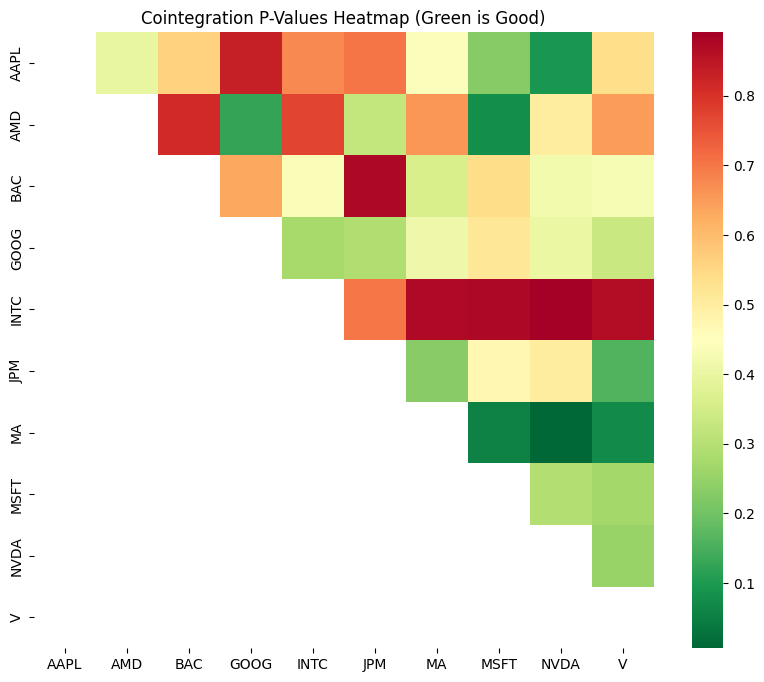


=== Cointegrated Pairs Found (P-value < 0.05) ===
Pair: MA vs NVDA | P-value: 0.00619


In [23]:
# 5. แสดงผลลัพธ์ (Visualization)
# สร้าง Heatmap ของ P-values (สีเข้ม = P-value ต่ำ = ดี)
plt.figure(figsize=(10, 8))
sns.heatmap(pvalues, xticklabels=data.columns, yticklabels=data.columns, cmap='RdYlGn_r', mask = (pvalues >= 0.99))
plt.title('Cointegration P-Values Heatmap (Green is Good)')
plt.show()

# พิมพ์รายชื่อคู่ที่ผ่านเกณฑ์
print("\n=== Cointegrated Pairs Found (P-value < 0.05) ===")
for pair in pairs:
    print(f"Pair: {pair[0]} vs {pair[1]} | P-value: {pair[2]:.5f}")

อธิบายผลลัพธ์ที่จะได้
1. Heatmap: จะเห็นตารางสีๆ จุดที่เป็น "สีเขียวเข้ม" คือจุดที่ P-value ต่ำมากๆ นั่นคือคู่ที่มีโอกาสเป็น Pairs Trading ได้

2. List of Pairs: โปรแกรมจะปริ้นท์ออกมาเลยว่าคู่ไหนผ่านเกณฑ์บ้าง เช่น อาจจะเจอ JPM vs BAC (แบงค์เหมือนกัน) หรือ V vs MA (บัตรเครดิตเหมือนกัน)

ข้อควรระวัง (Spurious Correlation)
คอมพิวเตอร์อาจจะบอกว่าหุ้น AAPL (ขายไอโฟน) กับ JPM (ธนาคาร) เป็นคู่กัน เพราะ P-value ต่ำ

- นี่คือกับดัก: ในทางสถิติมันอาจจะบังเอิญเดินเหมือนกันในช่วง 2 ปีที่ผ่านมา แต่ในทางธุรกิจ มันไม่มีความสัมพันธ์กันเลย

- วิธีแก้: ต้องใช้ Human Logic กรองอีกชั้นเสมอ เลือกเทรดเฉพาะคู่ที่ "สมเหตุสมผลทางธุรกิจ" เท่านั้น (เช่น Sector เดียวกัน)

## Position Sizing (การกำหนดขนาดไม้เทรด)

Concept: ทำไมห้ามลงเงิน 50/50?

สมมติคุณเทรดคู่ PEP (ราคา $170) vs KO (ราคา $60)ค่า Beta จากสมการ OLS ได้ 0.5
(แปลว่า PEP 1 หุ้น เคลื่อนไหวเท่ากับ KO 0.5 หุ้น? คำตอบคือไม่ใช่ และสมการคือ $P_{KO} = \beta P_{PEP} + \dots$)

สมการคือ: Price_Y = Beta * Price_X + Spread

ถ้าเราจะเทรด Spread 1 หน่วย:
- เราต้อง Long Y จำนวน 1 หุ้น
- และ Short X จำนวน Beta หุ้น

ถ้าลงเงิน $5,000 ซื้อ Y และ $5,000 Short X (Dollar Neutral) พอร์ตคุณอาจจะเอียง เพราะความผันผวนของทั้งสองตัวไม่เท่ากัน เราจึงต้องใช้ "Beta Neutral Sizing" 

สูตรคำนวณจำนวนหุ้น (The Formula)

สมมติมีเงินทุน (Capital) $10,000 เราจะแบ่งเงินยังไง?
1. หา Package Size: การซื้อ 1 หน่วย spread ต้องใช้เงินเท่าไหร่?
   $$Cost_{PerUnit} = (1 \times Price_Y) + (\beta \times Price_X)$$
   (หมายเหตุ: ในทางปฏิบัติเราคิดเป็นมูลค่า Absolute ของทั้งสองขารวมกัน)

2. หาจำนวน Unit ที่ซื้อได้:
   $$Units = \frac{Total Capital}{Cost_{PerUnit}}$$

3. แปลงเป็นจำนวนหุ้น:

   - หุ้น Y = $1 \times Units$
   - หุ้น X = $\beta \times Units$

## Implementation โค้ดคำนวณ Position Sizing

In [24]:
import math

def calculate_position_size(capital, price_y, price_x, beta):
    """
    คำนวณจำนวนหุ้นสำหรับ Pairs Trading แบบ Beta Neutral
    
    Parameters:
    capital (float): เงินทุนทั้งหมดสำหรับคู่นี้ (USD)
    price_y (float): ราคาหุ้นตัวตาม (Dependent Variable - Y) -> ตัวที่เราจะ Long 1 ส่วน
    price_x (float): ราคาหุ้นตัวนำ (Independent Variable - X) -> ตัวที่เราจะ Short Beta ส่วน
    beta (float): Hedge Ratio จาก OLS
    
    Returns:
    dict: จำนวนหุ้นที่ต้องเทรด
    """
    
    # 1. มูลค่าต่อ 1 หน่วย Spread (สมมติถือทั้งสองขา)
    # เราใช้ Absolute เพราะการ Short ก็ต้องวางเงินประกัน (Margin)
    # สมมติ Beta = 1.2, แปลว่าซื้อ Y 1 หุ้น ต้อง Short X 1.2 หุ้น
    package_cost = (1 * price_y) + (abs(beta) * price_x)
    
    # 2. ซื้อได้กี่ Package (ปัดเศษลงเพื่อ play safe)
    num_packages = math.floor(capital / package_cost)
    
    # 3. จำนวนหุ้นแต่ละขา
    qty_y = num_packages * 1
    qty_x = math.floor(num_packages * beta)
    
    # 4. มูลค่าจริงที่ใช้
    total_exposure = (qty_y * price_y) + (qty_x * price_x)
    
    return {
        "Long_Ticker_Y": qty_y,
        "Short_Ticker_X": qty_x,
        "Total_Capital_Used": total_exposure,
        "Leverage_Ratio": f"1 : {beta:.2f}"
    }

In [25]:
# --- ทดลองเรียกใช้ ---
# สมมติเทรดคู่ KO (Y) vs PEP (X)
# จาก Code ก่อนหน้า สมมติเราหา Beta ได้ 0.35
capital = 10000 # มีเงิน $10,000
price_ko = 60.50   # ราคา KO (Y)
price_pep = 168.20 # ราคา PEP (X)
beta = 0.35        # Hedge Ratio

order_plan = calculate_position_size(capital, price_ko, price_pep, beta)

print("=== ORDER PLAN ===")
print(f"Capital: ${capital}")
print(f"Action: LONG KO {order_plan['Long_Ticker_Y']} shares")
print(f"Action: SHORT PEP {order_plan['Short_Ticker_X']} shares")
print(f"Value Ratio: 1 KO per {beta} PEP")

=== ORDER PLAN ===
Capital: $10000
Action: LONG KO 83 shares
Action: SHORT PEP 29 shares
Value Ratio: 1 KO per 0.35 PEP


ส่วนสำคัญ: Risk Management (Stop Loss)

ตอนนี้เรารู้วิธีเข้า (Entry) และขนาดไม้ (Sizing) แล้ว สิ่งสุดท้ายก่อนเทรดคือ "ทางหนีไฟ (Exit when wrong)"

Pairs Trading มักจะเจ็บหนักเมื่อ Correlation Breakdown (เช่น บริษัทหนึ่งโดนฟ้องล้มละลาย แต่อีกบริษัทปกติ) Spread จะฉีกออกไปไม่กลับมา

กฎเหล็กสำหรับ Stop Loss:Z-Score Stop:
1. ถ้า Z-Score วิ่งไปถึง $\pm 4$ หรือ $\pm 5$ (เหตุการณ์ระดับวิกฤต) ต้อง Cut Loss ทันที อย่าหวังว่ามันจะกลับมา เพราะมันอาจจะเป็น "New Normal"
2. Time Stop: ถ้าถือสถานะมาเกิน 30 วัน แล้วราคายังไม่กลับมาที่เดิม (Spread ไม่หุบ) ให้ปิดสถานะทันที เพื่อเอาเงินไปเทรดคู่อื่น (Time Value of Money)

# The Master Script: Pairs Trading Bot

In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import math

class PairsTradingBot:
    def __init__(self, ticker_y, ticker_x, capital=10000, entry_z=2.0, exit_z=0.0, window=30):
        """
        ticker_y: หุ้นตัวตาม (Dependent) -> ฝั่งที่เราจะ Long 1 หน่วย
        ticker_x: หุ้นตัวนำ (Independent) -> ฝั่งที่เราจะ Short Beta หน่วย
        capital: เงินทุนสำหรับคู่นี้ (USD)
        window: ระยะเวลา Rolling Window สำหรับคำนวณ Z-Score
        """
        self.t_y = ticker_y
        self.t_x = ticker_x
        self.capital = capital
        self.entry_z = entry_z
        self.exit_z = exit_z
        self.window = window
        self.data = None
        self.beta = None
        self.latest_z = None
        
    def download_data(self, start_date='2023-01-01', end_date=None):
        print(f"📥 Downloading data for {self.t_y} and {self.t_x}...")
        tickers = [self.t_y, self.t_x]
        df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
        
        # Clean Data
        df = df.dropna()
        self.data = df
        print("✅ Data ready.")
        
    def analyze_model(self):
        # 1. Calculate Hedge Ratio (Beta) using OLS
        # (ใช้ Log Price เพื่อความแม่นยำในระยะยาว แต่ใช้ Price ปกติก็เข้าใจง่าย)
        Y = self.data[self.t_y]
        X = self.data[self.t_x]
        
        X_const = sm.add_constant(X)
        model = sm.OLS(Y, X_const).fit()
        self.beta = model.params[self.t_x]
        
        print(f"📊 Hedge Ratio (Beta): {self.beta:.4f}")
        
        # 2. Calculate Spread
        self.data['Spread'] = Y - (self.beta * X)
        
        # 3. Calculate Z-Score (Rolling)
        spread_mean = self.data['Spread'].rolling(window=self.window).mean()
        spread_std = self.data['Spread'].rolling(window=self.window).std()
        
        self.data['Z_Score'] = (self.data['Spread'] - spread_mean) / spread_std
        self.latest_z = self.data['Z_Score'].iloc[-1]
        
    def plot_performance(self):
        # Plot Z-Score
        plt.figure(figsize=(12, 6))
        z_score = self.data['Z_Score']
        
        plt.plot(z_score, label='Z-Score', alpha=0.7)
        plt.axhline(0, color='black', lw=1.5)
        plt.axhline(self.entry_z, color='red', linestyle='--', label='Sell Threshold')
        plt.axhline(-self.entry_z, color='green', linestyle='--', label='Buy Threshold')
        plt.fill_between(z_score.index, self.entry_z, z_score, where=(z_score > self.entry_z), color='red', alpha=0.3)
        plt.fill_between(z_score.index, -self.entry_z, z_score, where=(z_score < -self.entry_z), color='green', alpha=0.3)
        
        plt.title(f'Pairs Trading Signal: {self.t_y} vs {self.t_x} (Current Z: {self.latest_z:.2f})')
        plt.legend()
        plt.show()

    def get_trade_decision(self):
        """
        ฟังก์ชันตัดสินใจหน้างาน (Execution)
        คำนวณจำนวนหุ้นที่ต้องซื้อ/ขาย ณ ราคาปัจจุบัน
        """
        price_y = self.data[self.t_y].iloc[-1]
        price_x = self.data[self.t_x].iloc[-1]
        z = self.latest_z
        
        print("\n" + "="*40)
        print(f"🤖 TRADING BOT DECISION (Date: {self.data.index[-1].date()})")
        print("="*40)
        print(f"Current Z-Score: {z:.2f}")
        print(f"Prices: {self.t_y}=${price_y:.2f} | {self.t_x}=${price_x:.2f}")
        
        # Logic การตัดสินใจ
        signal = "WAIT / HOLD"
        action_y = "None"
        action_x = "None"
        
        if z < -self.entry_z:
            signal = "🟢 LONG ENTRY (Spread ถูกเกินไป)"
            action_y = "BUY"
            action_x = "SELL (Short)"
        elif z > self.entry_z:
            signal = "🔴 SHORT ENTRY (Spread แพงเกินไป)"
            action_y = "SELL (Short)"
            action_x = "BUY"
        elif abs(z) < 0.5: # ใกล้เคียง 0
            signal = "⚪ EXIT / TAKE PROFIT (เข้าสู่สมดุล)"
            action_y = "CLOSE POS"
            action_x = "CLOSE POS"
            
        print(f"Signal: {signal}")
        
        # ถ้ามีสัญญาณซื้อ/ขาย ให้คำนวณ Size
        if "ENTRY" in signal:
            # คำนวณ Position Sizing (Beta Neutral)
            # Cost per package = Price Y + (Beta * Price X)
            package_cost = price_y + (abs(self.beta) * price_x)
            num_packages = math.floor(self.capital / package_cost)
            
            qty_y = int(num_packages)
            qty_x = int(num_packages * self.beta)
            
            total_val = (qty_y * price_y) + (qty_x * price_x)
            
            print("-" * 40)
            print(f"📦 EXECUTION PLAN (Capital: ${self.capital})")
            print(f"1. {action_y} {self.t_y}: {qty_y} Shares")
            print(f"2. {action_x} {self.t_x}: {qty_x} Shares")
            print(f"   (Implied Ratio: 1 {self.t_y} : {self.beta:.2f} {self.t_x})")
            print(f"   Est. Value Used: ${total_val:.2f}")
            print("-" * 40)
            
        else:
            print("Action: No new entry trade required.")

คู่มือใช้งาน Script นี้ (User Manual)
1. การทำงานของ Class
    - Initialization: ใส่ชื่อหุ้น ticker_y (ตัวที่เราสนใจหลัก) และ ticker_x (คู่เทียบ) พร้อมเงินทุน

    - Analyze: มันจะวิ่งไปหาค่า Beta (ความสัมพันธ์) อัตโนมัติ และสร้าง Z-Score ให้

    - Decision: นี่คือทีเด็ดครับ มันจะเช็คราคา "ล่าสุด" (บรรทัดสุดท้ายของข้อมูล) แล้วบอกเลยว่าคุณต้อง Long กี่หุ้น และ Short กี่หุ้น เพื่อให้พอร์ตเป็น Market Neutral ตามทฤษฎี

2. วิธีอ่านค่า Output
เมื่อคุณรันคำสั่ง bot.get_trade_decision() คุณจะเจอผลลัพธ์แบบนี้:

    - Scenario 1 (Z-Score = -2.5): บอทจะตะโกนว่า "🟢 LONG ENTRY" และคำนวณให้เลยว่า ต้องซื้อ KO 50 หุ้น และ Short PEP 18 หุ้น (ตัวเลขสมมติ)

    - Scenario 2 (Z-Score = 0.1): บอทจะบอกว่า "⚪ EXIT" แปลว่าถ้ามีของอยู่ให้ปิดทำกำไรได้แล้ว หรือถ้าไม่มีของก็นั่งทับมือไว้

📥 Downloading data for MSFT and GOOGL...


[*********************100%***********************]  2 of 2 completed

✅ Data ready.
📊 Hedge Ratio (Beta): 1.2901


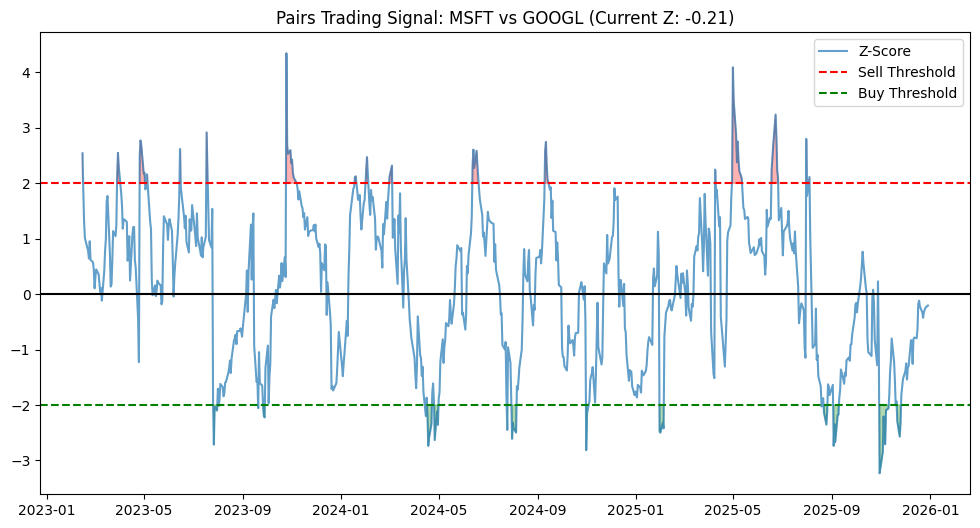


🤖 TRADING BOT DECISION (Date: 2025-12-29)
Current Z-Score: -0.21
Prices: MSFT=$487.10 | GOOGL=$313.56
Signal: ⚪ EXIT / TAKE PROFIT (เข้าสู่สมดุล)
Action: No new entry trade required.


In [31]:
# --- วิธีใช้งาน (Usage) ---

# 1. สร้างบอท (ตั้งค่าหุ้นและเงินทุน)
bot = PairsTradingBot(ticker_y='MSFT', ticker_x='GOOGL', capital=10000)

# 2. ดึงข้อมูล
bot.download_data(start_date='2023-01-01')

# 3. วิเคราะห์โมเดล
bot.analyze_model()

# 4. ดูผลลัพธ์กราฟ
bot.plot_performance()

# 5. ขอคำแนะนำการเทรดวันนี้
bot.get_trade_decision()

# The Master Script: Pairs Trading Bot (With Stop Loss)

สิ่งที่เพิ่มเข้ามา:
1. Parameter stop_loss_z: ค่า Z-Score ที่ยอมแพ้ (ปกติมักตั้งไว้ที่ 3.5 ถึง 4.0 SD)

2. Safety Logic: เช็ค Stop Loss เป็นอันดับแรก ถ้า Z-Score ทะลุเพดานนี้ บอทจะสั่ง "CLOSE / CUT LOSS" ทันที ไม่ว่าจะเกิดอะไรขึ้น

3. Visual: เพิ่มเส้นสีม่วงในกราฟ เพื่อให้เห็นจุดอันตรายชัดเจน

In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import math

class PairsTradingBot:
    def __init__(self, ticker_y, ticker_x, capital=10000, entry_z=2.0, exit_z=0.0, stop_loss_z=4.0, window=30):
        """
        stop_loss_z: ค่า Z-Score สูงสุดที่ยอมรับได้ หากเกินนี้ถือว่า "ความสัมพันธ์พัง" ให้ Cut Loss
        """
        self.t_y = ticker_y
        self.t_x = ticker_x
        self.capital = capital
        self.entry_z = entry_z
        self.exit_z = exit_z
        self.stop_loss_z = stop_loss_z # <-- New Parameter
        self.window = window
        self.data = None
        self.beta = None
        self.latest_z = None
        
    def download_data(self, start_date='2023-01-01', end_date=None):
        print(f"📥 Downloading data for {self.t_y} and {self.t_x}...")
        tickers = [self.t_y, self.t_x]
        # โหลดข้อมูล
        df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
        df = df.dropna()
        self.data = df
        print("✅ Data ready.")
        
    def analyze_model(self):
        # 1. หา Hedge Ratio (Beta)
        Y = self.data[self.t_y]
        X = self.data[self.t_x]
        X_const = sm.add_constant(X)
        model = sm.OLS(Y, X_const).fit()
        self.beta = model.params[self.t_x]
        
        print(f"📊 Hedge Ratio (Beta): {self.beta:.4f}")
        
        # 2. สร้าง Spread และ Z-Score
        self.data['Spread'] = Y - (self.beta * X)
        spread_mean = self.data['Spread'].rolling(window=self.window).mean()
        spread_std = self.data['Spread'].rolling(window=self.window).std()
        
        self.data['Z_Score'] = (self.data['Spread'] - spread_mean) / spread_std
        self.latest_z = self.data['Z_Score'].iloc[-1]
        
    def plot_performance(self):
        plt.figure(figsize=(12, 6))
        z_score = self.data['Z_Score']
        
        plt.plot(z_score, label='Z-Score', alpha=0.7, color='blue')
        plt.axhline(0, color='black', lw=1.5, label='Mean (Exit)')
        
        # เส้น Entry
        plt.axhline(self.entry_z, color='orange', linestyle='--', label='Sell Entry')
        plt.axhline(-self.entry_z, color='orange', linestyle='--', label='Buy Entry')
        
        # เส้น Stop Loss (เพิ่มใหม่ สีม่วง)
        plt.axhline(self.stop_loss_z, color='purple', linestyle='-', linewidth=2, label='STOP LOSS (+)')
        plt.axhline(-self.stop_loss_z, color='purple', linestyle='-', linewidth=2, label='STOP LOSS (-)')
        
        # ถมสีพื้นที่ Stop Loss Zone
        plt.fill_between(z_score.index, self.stop_loss_z, z_score, where=(z_score > self.stop_loss_z), color='purple', alpha=0.5)
        plt.fill_between(z_score.index, -self.stop_loss_z, z_score, where=(z_score < -self.stop_loss_z), color='purple', alpha=0.5)
        
        plt.title(f'Pairs Trading Signal: {self.t_y} vs {self.t_x} (Current Z: {self.latest_z:.2f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def get_trade_decision(self):
        price_y = self.data[self.t_y].iloc[-1]
        price_x = self.data[self.t_x].iloc[-1]
        z = self.latest_z
        
        print("\n" + "="*50)
        print(f"🤖 TRADING BOT DECISION (Date: {self.data.index[-1].date()})")
        print("="*50)
        print(f"Current Z-Score: {z:.2f}")
        print(f"Prices: {self.t_y}=${price_y:.2f} | {self.t_x}=${price_x:.2f}")
        
        # --- Logic Hierarchy (ลำดับความสำคัญ) ---
        # 1. เช็ค Stop Loss ก่อนเสมอ (Safety First)
        # 2. เช็คจุดเข้า Entry
        # 3. เช็คจุดออก Exit (Profit)
        
        signal = "WAIT / HOLD"
        action_desc = "No Action"
        
        # 1. Check Stop Loss
        if abs(z) >= self.stop_loss_z:
            signal = "☠️ STOP LOSS / DANGER ZONE"
            action_desc = "CLOSE ALL POSITIONS IMMEDIATELY (Correlation Breakdown)"
            
        # 2. Check Entry Signals (ถ้ายังไม่ถึงจุดตาย)
        elif z < -self.entry_z:
            signal = "🟢 LONG ENTRY (Spread ถูก)"
            action_desc = f"BUY {self.t_y} / SHORT {self.t_x}"
        elif z > self.entry_z:
            signal = "🔴 SHORT ENTRY (Spread แพง)"
            action_desc = f"SHORT {self.t_y} / BUY {self.t_x}"
            
        # 3. Check Exit Signal (Normal Profit)
        elif abs(z) < 0.5: # เข้าใกล้ 0
            signal = "⚪ NORMAL EXIT (Take Profit)"
            action_desc = "Close Positions (Back to Mean)"
            
        print(f"Signal Status: {signal}")
        print(f"Action: {action_desc}")
        
        # คำนวณ Size เฉพาะกรณีที่เป็น Entry Signal (และไม่เกิน Stop Loss)
        if "ENTRY" in signal and "STOP" not in signal:
            package_cost = price_y + (abs(self.beta) * price_x)
            num_packages = math.floor(self.capital / package_cost)
            
            qty_y = int(num_packages)
            qty_x = int(num_packages * self.beta)
            total_val = (qty_y * price_y) + (qty_x * price_x)
            
            print("-" * 50)
            print(f"📦 EXECUTION PLAN (Capital: ${self.capital})")
            print(f"   > {qty_y} shares of {self.t_y}")
            print(f"   > {qty_x} shares of {self.t_x}")
            print(f"   (Hedge Ratio Beta: {self.beta:.4f})")
            print(f"   Total Value Exposure: ${total_val:.2f}")
            print("-" * 50)
            
        elif "STOP LOSS" in signal:
            print("⚠️ WARNING: ความสัมพันธ์ของราคาผิดปกติเกิน 4 SD แนะนำให้ล้างพอร์ตและหยุดเทรดคู่นี้ชั่วคราว")

📥 Downloading data for KO and PEP...


[*********************100%***********************]  2 of 2 completed

✅ Data ready.
📊 Hedge Ratio (Beta): -0.2758


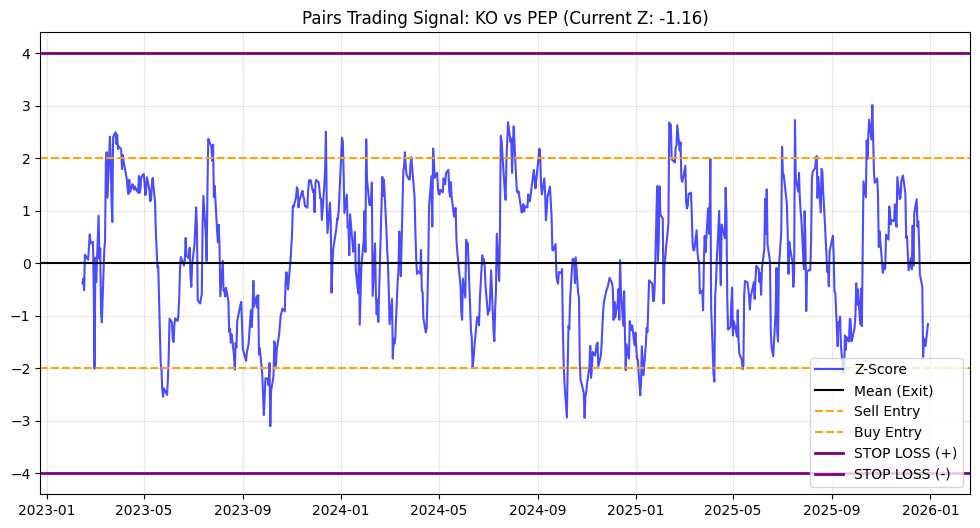


🤖 TRADING BOT DECISION (Date: 2025-12-29)
Current Z-Score: -1.16
Prices: KO=$70.16 | PEP=$144.24
Signal Status: WAIT / HOLD
Action: No Action


In [34]:
# --- การใช้งาน ---
# กำหนด Stop Loss ไว้ที่ 4.0 SD (ค่ามาตรฐานคือ 3.5 - 4.0)
bot = PairsTradingBot(ticker_y='KO', ticker_x='PEP', capital=10000, stop_loss_z=4.0)

bot.download_data(start_date='2023-01-01')
bot.analyze_model()
bot.plot_performance()
bot.get_trade_decision()

# The Master Script: Pairs Trading Bot (With Dynamic Volatility Filter)

สิ่งที่เพิ่มมาคือ 

1. คำนวณ Volatility Ratio: เปรียบเทียบความผันผวนระยะสั้น (5 วัน) กับระยะยาว (60 วัน) ของ Spread

2. Dynamic Thresholds:

    - ถ้าตลาดปกติ (Ratio < 1.5): ใช้ค่า Entry 2.0 / Stop 4.0 ตามเดิม

    - ถ้าตลาดผันผวนสูง (Ratio >= 1.5): ขยาย ค่า Entry เป็น 2.5 และ Stop เป็น 5.0 ทันที (เข้ายากขึ้น ตายยากขึ้น)

3. Smart Decision: ใช้ค่า Threshold ใหม่นี้ในการตัดสินใจซื้อขายทันที

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import math

class PairsTradingBot:
    def __init__(self, ticker_y, ticker_x, capital=10000, 
                 entry_z=2.0, exit_z=0.0, stop_loss_z=4.0, window=30):
        self.t_y = ticker_y
        self.t_x = ticker_x
        self.capital = capital
        self.entry_z = entry_z          # ค่ามาตรฐาน
        self.exit_z = exit_z
        self.stop_loss_z = stop_loss_z  # ค่ามาตรฐาน
        self.window = window
        self.data = None
        self.beta = None
        self.latest_z = None
        self.vol_ratio = None           # เก็บค่าอัตราส่วนความผันผวน
        
    def download_data(self, start_date='2023-01-01', end_date=None):
        print(f"📥 Downloading data for {self.t_y} and {self.t_x}...")
        tickers = [self.t_y, self.t_x]
        df = yf.download(tickers, start=start_date, end=end_date,auto_adjust=False)['Adj Close']
        df = df.dropna()
        self.data = df
        print("✅ Data ready.")
        
    def analyze_model(self):
        # 1. Hedge Ratio (Beta)
        Y = self.data[self.t_y]
        X = self.data[self.t_x]
        X_const = sm.add_constant(X)
        model = sm.OLS(Y, X_const).fit()
        self.beta = model.params[self.t_x]
        print(f"📊 Hedge Ratio (Beta): {self.beta:.4f}")
        
        # 2. Spread & Z-Score
        self.data['Spread'] = Y - (self.beta * X)
        spread_mean = self.data['Spread'].rolling(window=self.window).mean()
        spread_std = self.data['Spread'].rolling(window=self.window).std()
        self.data['Z_Score'] = (self.data['Spread'] - spread_mean) / spread_std
        self.latest_z = self.data['Z_Score'].iloc[-1]
        
        # 3. --- Volatility Filter Calculation (ส่วนที่เพิ่มมาใหม่) ---
        # Short-term Volatility (5 วัน) vs Long-term Volatility (60 วัน)
        short_vol = self.data['Spread'].rolling(window=5).std()
        long_vol = self.data['Spread'].rolling(window=60).std()
        
        # คำนวณ Ratio (ใช้ค่าล่าสุด)
        self.data['Vol_Ratio'] = short_vol / long_vol
        self.vol_ratio = self.data['Vol_Ratio'].iloc[-1]
        
    def plot_performance(self):
        # Logic การปรับ Threshold สำหรับการ plot (เพื่อให้เห็นภาพบนกราฟ)
        # หมายเหตุ: ในกราฟนี้จะ plot เป็นเส้นตรงแบบ Static เพื่อความง่ายในการดู
        # แต่การตัดสินใจจริงจะใช้ Dynamic Logic
        plt.figure(figsize=(12, 6))
        z_score = self.data['Z_Score']
        
        plt.plot(z_score, label='Z-Score', alpha=0.7, color='blue')
        plt.axhline(0, color='black', lw=1.5, label='Mean')
        plt.axhline(self.entry_z, color='orange', linestyle='--', label=f'Base Entry (+{self.entry_z})')
        plt.axhline(-self.entry_z, color='orange', linestyle='--', label=f'Base Entry (-{self.entry_z})')
        plt.axhline(self.stop_loss_z, color='purple', linestyle='-', label=f'Base Stop (+{self.stop_loss_z})')
        
        plt.title(f'Pairs Trading: {self.t_y} vs {self.t_x} (Vol Ratio: {self.vol_ratio:.2f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def get_trade_decision(self):
        price_y = self.data[self.t_y].iloc[-1]
        price_x = self.data[self.t_x].iloc[-1]
        z = self.latest_z
        
        print("\n" + "="*50)
        print(f"🤖 TRADING BOT DECISION (Date: {self.data.index[-1].date()})")
        print("="*50)
        
        # --- Dynamic Threshold Logic ---
        current_entry = self.entry_z
        current_stop = self.stop_loss_z
        mode = "Normal Mode"
        
        # ถ้าความผันผวนระยะสั้น สูงกว่าระยะยาว 1.5 เท่า (ตลาดกระชาก)
        if self.vol_ratio > 1.5:
            current_entry = self.entry_z + 0.5  # ขยาย Entry (เช่น 2.0 -> 2.5)
            current_stop = self.stop_loss_z + 1.0 # ขยาย Stop (เช่น 4.0 -> 5.0)
            mode = "⚠️ HIGH VOLATILITY MODE (Expanded Thresholds)"
            
        print(f"Market Status: {mode}")
        print(f"Volatility Ratio: {self.vol_ratio:.2f} (Short/Long Term Vol)")
        print(f"Active Thresholds -> Entry: ±{current_entry:.1f} | Stop: ±{current_stop:.1f}")
        print(f"Current Z-Score: {z:.2f}")
        print("-" * 50)
        
        # --- Logic Decision (ใช้ current_entry และ current_stop) ---
        signal = "WAIT / HOLD"
        action_desc = "No Action"
        
        # 1. Check Dynamic Stop Loss
        if abs(z) >= current_stop:
            signal = "☠️ STOP LOSS TRIGGERED"
            action_desc = "CLOSE ALL POSITIONS (Correlation Breakdown)"
            
        # 2. Check Dynamic Entry
        elif z < -current_entry:
            signal = "🟢 LONG ENTRY"
            action_desc = f"BUY {self.t_y} / SHORT {self.t_x}"
        elif z > current_entry:
            signal = "🔴 SHORT ENTRY"
            action_desc = f"SHORT {self.t_y} / BUY {self.t_x}"
            
        # 3. Check Exit (คงที่ที่ 0.5 หรือปรับตามชอบ)
        elif abs(z) < 0.5:
            signal = "⚪ NORMAL EXIT"
            action_desc = "Close Positions (Back to Mean)"
            
        print(f"Signal: {signal}")
        print(f"Action: {action_desc}")
        
        # Sizing Calculation
        if "ENTRY" in signal and "STOP" not in signal:
            package_cost = price_y + (abs(self.beta) * price_x)
            num_packages = math.floor(self.capital / package_cost)
            qty_y = int(num_packages)
            qty_x = int(num_packages * self.beta)
            total_val = (qty_y * price_y) + (qty_x * price_x)
            
            print("-" * 50)
            print(f"📦 EXECUTION PLAN (Capital: ${self.capital})")
            print(f"   > {qty_y} shares of {self.t_y}")
            print(f"   > {qty_x} shares of {self.t_x}")
            print(f"   Total Value: ${total_val:.2f}")

📥 Downloading data for NVDA and AMD...


[*********************100%***********************]  2 of 2 completed

✅ Data ready.
📊 Hedge Ratio (Beta): 0.9028


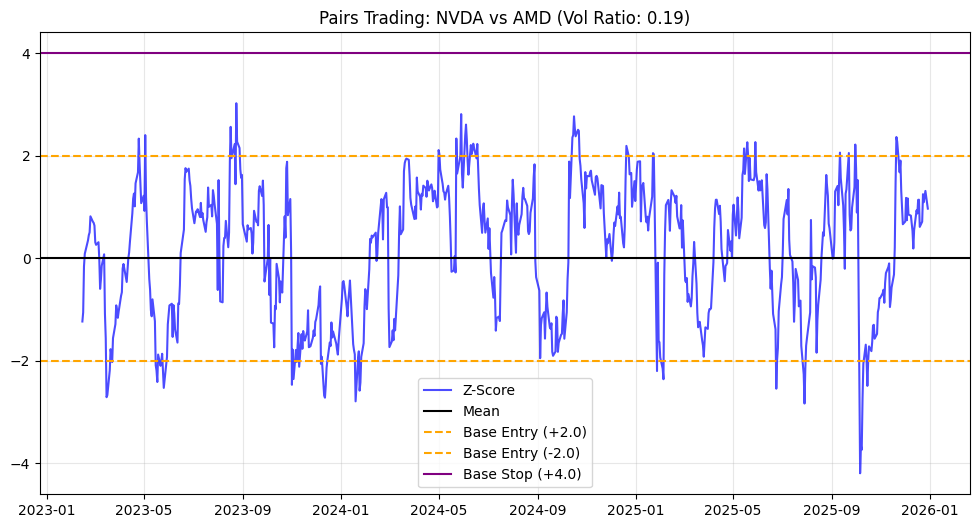


🤖 TRADING BOT DECISION (Date: 2025-12-29)
Market Status: Normal Mode
Volatility Ratio: 0.19 (Short/Long Term Vol)
Active Thresholds -> Entry: ±2.0 | Stop: ±4.0
Current Z-Score: 0.97
--------------------------------------------------
Signal: WAIT / HOLD
Action: No Action


In [37]:
# --- ทดลองรัน ---
# ลองเปลี่ยน ticker เป็นหุ้นที่มีข่าวแรงๆ ช่วงนี้ดูจะเห็น Volatility Filter ทำงาน
bot = PairsTradingBot(ticker_y='NVDA', ticker_x='AMD', capital=10000)
bot.download_data(start_date='2023-01-01')
bot.analyze_model()
bot.plot_performance()
bot.get_trade_decision()

เมื่อรัน bot.get_trade_decision() ให้สังเกตบรรทัด Market Status:

1. ถ้าขึ้นว่า Normal Mode:

    - แปลว่าตลาดปกติ บอทจะใช้ Entry ±2.0 ตามเดิม

2. ถ้าขึ้นว่า ⚠️ HIGH VOLATILITY MODE:

    - แปลว่าช่วง 5 วันที่ผ่านมา Spread เหวี่ยงแรงมาก (Vol Ratio > 1.5)

    - บอทจะแจ้งว่า "Active Thresholds -> Entry: ±2.5"

    - ผลลัพธ์: สมมติ Z-Score ตอนนี้อยู่ที่ 2.2

        - ถ้าเป็นโหมดปกติ บอทจะสั่ง "เข้าเทรด" (เสี่ยงรับมีด)

        - แต่พอเป็นโหมดนี้ บอทจะบอกให้ "Wait" (เพราะยังไม่ถึง 2.5) ช่วยเซฟเราจากการเข้าเร็วเกินไป